# Phase 1 — SQL Analytics Layer
## Hospital Operations & Revenue Risk Intelligence Platform

**Business Goal:** Create a reliable, queryable hospital data layer that
leadership can trust for operational and financial decision-making.

**Imports from:** `phase1_utils.py` — all setup, helpers, and constants  
**Output folder:** none (SQL analysis only — charts inline)

> All CSV files must be in the **same folder** as this notebook.


## 1. Setup — Import Everything from phase1_utils

In [2]:
# ── Imports — Phase 1: SQL Analytics Layer ────────────────────────────────

# phase1_utils: foundation imports (Utils/ must be marked as Sources Root)
from phase1_utils import (
    notebook_setup,    # one-call setup: pandas config, plot style, DB, output folder
    run_query,         # SQL helper: run → print labelled result → return DataFrame
    RISK_COLORS,       # {'Low':'#55A868', 'Medium':'#DD8452', 'High':'#C44E52'}
    STATUS_COLORS,     # {'Paid':'#55A868', 'Pending':'#DD8452', 'Rejected':'#C44E52'}
    DEPT_COLORS,       # list of 6 colours for departments
    INS_COLORS,        # list of 4 colours for insurance providers
    ENCODING_MAPS,     # categorical → numeric encoding maps
    save_fig,          # save + show current matplotlib figure in one call
)

# Standard libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import display

# ── One-call setup ────────────────────────────────────────────────────────
# Handles: pandas display options (no scientific notation), consistent plot
# style, SQLite DB with indexes and views, and optional output folder.
ctx = notebook_setup(
    phase_output_dir = None,   # Phase 1 has no output folder — charts show inline
    load_merged      = False,  # Phase 1 uses SQL only, not the pandas merged DF
)

con      = ctx['con']       # SQLite connection — used by run_query()
patients = ctx['patients']  # raw patients DataFrame
visits   = ctx['visits']    # raw visits DataFrame
billing  = ctx['billing']   # raw billing DataFrame

🔧 phase1_utils — notebook setup
────────────────────────────────────────
📦 Loading CSVs into SQLite...
  patients :  5,000 rows × 7 cols
  visits   : 25,000 rows × 8 cols
  billing  : 25,000 rows × 7 cols
  ✅ SQLite DB ready — 7 indexes + 2 views created.
────────────────────────────────────────
✅ Setup complete. Everything is ready.



## 2. Schema Design

The full production DDL — the SQL a DBA would run in PostgreSQL.
SQLite already has the tables from `notebook_setup()` above.

### Design decisions

| Decision | Reason |
|---|---|
| `patient_id` PRIMARY KEY | Prevents duplicate patient records |
| `visit_id` PRIMARY KEY | Every visit is uniquely identifiable |
| FOREIGN KEY `patient_id → patients` | Prevents visits for non-existent patients |
| FOREIGN KEY `visit_id → visits` | Prevents bills for non-existent visits |
| `CHECK (age BETWEEN 0 AND 120)` | Rejects impossible values at insert time |
| `CHECK (risk_score IN (...))` | Only valid risk levels allowed |
| `approved_amount` allows NULL | NULL = insurer hasn't responded yet |
| `payment_days` allows NULL | NULL = payment not yet received |


In [3]:
DDL = """
-- TABLE: patients
CREATE TABLE patients (
    patient_id         INTEGER  NOT NULL,
    age                INTEGER  NOT NULL  CHECK (age BETWEEN 0 AND 120),
    gender             TEXT     NOT NULL  CHECK (gender IN ('M','F')),
    city               TEXT     NOT NULL,
    insurance_provider TEXT     NOT NULL,
    chronic_flag       INTEGER  NOT NULL  CHECK (chronic_flag IN (0,1)),
    registration_date  TEXT     NOT NULL,
    PRIMARY KEY (patient_id)
);

-- TABLE: visits
CREATE TABLE visits (
    visit_id             INTEGER NOT NULL,
    patient_id           INTEGER NOT NULL,
    visit_date           TEXT    NOT NULL,
    department           TEXT    NOT NULL
                                 CHECK (department IN
                                 ('Cardiology','Orthopedics','ICU',
                                  'General','ER','Neurology')),
    visit_type           TEXT    NOT NULL CHECK (visit_type IN ('ER','OPD','ICU')),
    length_of_stay_hours REAL    CHECK (length_of_stay_hours >= 0),
    risk_score           TEXT    NOT NULL
                                 CHECK (risk_score IN ('Low','Medium','High')),
    doctor_id            INTEGER NOT NULL,
    PRIMARY KEY (visit_id),
    FOREIGN KEY (patient_id) REFERENCES patients (patient_id)
);

-- TABLE: billing
CREATE TABLE billing (
    bill_id         INTEGER NOT NULL,
    visit_id        INTEGER NOT NULL,
    billed_amount   REAL    NOT NULL CHECK (billed_amount >= 0),
    approved_amount REAL,            -- NULL = not yet approved
    claim_status    TEXT    NOT NULL
                            CHECK (claim_status IN ('Paid','Pending','Rejected')),
    payment_days    REAL,            -- NULL = not yet paid
    billing_date    TEXT    NOT NULL,
    PRIMARY KEY (bill_id),
    FOREIGN KEY (visit_id) REFERENCES visits (visit_id)
);
"""
print(DDL)
print("✅ Schema documented. Tables, indexes, and views already loaded by notebook_setup().")



-- TABLE: patients
CREATE TABLE patients (
    patient_id         INTEGER  NOT NULL,
    age                INTEGER  NOT NULL  CHECK (age BETWEEN 0 AND 120),
    gender             TEXT     NOT NULL  CHECK (gender IN ('M','F')),
    city               TEXT     NOT NULL,
    insurance_provider TEXT     NOT NULL,
    chronic_flag       INTEGER  NOT NULL  CHECK (chronic_flag IN (0,1)),
    registration_date  TEXT     NOT NULL,
    PRIMARY KEY (patient_id)
);

-- TABLE: visits
CREATE TABLE visits (
    visit_id             INTEGER NOT NULL,
    patient_id           INTEGER NOT NULL,
    visit_date           TEXT    NOT NULL,
    department           TEXT    NOT NULL
                                 CHECK (department IN
                                 ('Cardiology','Orthopedics','ICU',
                                  'General','ER','Neurology')),
    visit_type           TEXT    NOT NULL CHECK (visit_type IN ('ER','OPD','ICU')),
    length_of_stay_hours REAL    CHECK (length_of_stay_hou

## 3. Indexes & Views

Both were created automatically by `notebook_setup()` via `phase1_utils.setup_database()`.
Documented here for reference.

**Indexes (7):** `idx_visits_patient_id`, `idx_visits_department`, `idx_visits_risk_score`,
`idx_visits_visit_date`, `idx_billing_visit_id`, `idx_billing_claim_status`, `idx_billing_billing_date`

**Views (2):** `vw_hospital_master` (all 3 tables joined), `vw_visits_patients` (visits + patients)


In [4]:
import pandas as pd

# Verify indexes and views were created
print("=== Indexes ===")
idx = pd.read_sql("SELECT name FROM sqlite_master WHERE type='index' AND name LIKE 'idx_%'", con)
print(idx.to_string(index=False))

print("\n=== Views ===")
views = pd.read_sql("SELECT name FROM sqlite_master WHERE type='view'", con)
print(views.to_string(index=False))

print("\n=== Sample from vw_hospital_master ===")
from IPython.display import display
display(pd.read_sql("SELECT * FROM vw_hospital_master LIMIT 3", con))


=== Indexes ===
                    name
   idx_visits_patient_id
   idx_visits_department
   idx_visits_risk_score
   idx_visits_visit_date
    idx_billing_visit_id
idx_billing_claim_status
idx_billing_billing_date

=== Views ===
              name
vw_hospital_master
vw_visits_patients

=== Sample from vw_hospital_master ===


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,756,90,M,Bangalore,CareOne,1,2025-08-14,1,2025-10-18,Cardiology,ER,3.48,Low,169,1,"23,577.37",0.00,Rejected,16.00,2025-06-18
1,4102,30,M,Hyderabad,SecureLife,1,2025-10-29,2,2025-04-06,Orthopedics,OPD,15.31,High,148,2,"38,178.81","38,178.81",Paid,18.00,2025-10-09
2,2964,25,F,Chennai,HealthPlus,1,2025-07-04,3,2025-07-13,ICU,ER,34.36,Low,153,3,"5,038.97","5,038.97",Paid,NaN,2025-01-20


## 4. Operational Analysis Queries

### OPS-01 — Top 10 Departments by Visit Volume


────────────────────────────────────────────────────────────
  OPS-01 · Top 10 departments by visit volume
────────────────────────────────────────────────────────────


,department,total_visits,pct_of_total
0,General,4228,16.91
1,ER,4220,16.88
2,Neurology,4165,16.66
3,Orthopedics,4164,16.66
4,Cardiology,4159,16.64
5,ICU,4064,16.26



💡 Visits are spread evenly across all 6 departments (~4,000–4,200 each).


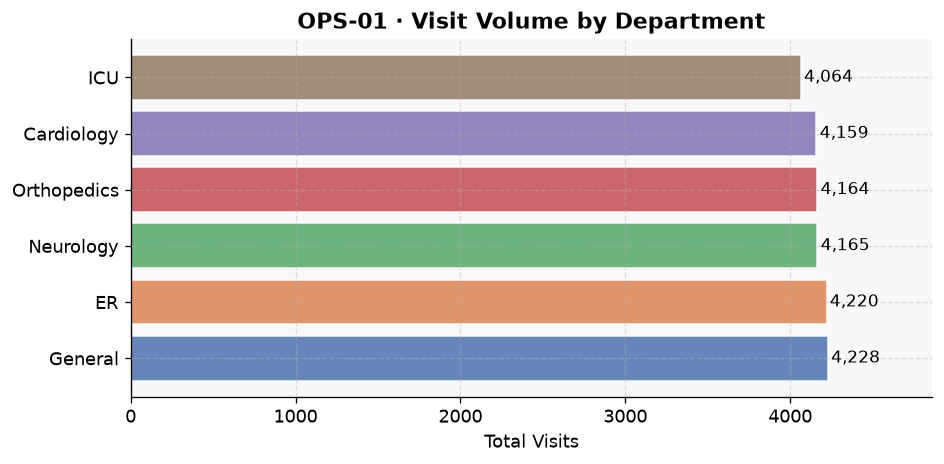

In [5]:
ops01 = run_query(con,
    "OPS-01 · Top 10 departments by visit volume",
    """
    SELECT department,
           COUNT(visit_id) AS total_visits,
           ROUND(COUNT(visit_id)*100.0/(SELECT COUNT(*) FROM visits),2) AS pct_of_total
    FROM visits
    GROUP BY department ORDER BY total_visits DESC LIMIT 10
    """,
    "Visits are spread evenly across all 6 departments (~4,000–4,200 each).")

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(ops01['department'], ops01['total_visits'], color=DEPT_COLORS, edgecolor='white', alpha=0.85)
ax.set_xlabel('Total Visits'); ax.set_title('OPS-01 · Visit Volume by Department')
for bar in ax.patches:
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)
ax.set_xlim(0, ops01['total_visits'].max()*1.15)
plt.tight_layout(); plt.show()


### OPS-02 — Top 5 Departments by Average Length of Stay


────────────────────────────────────────────────────────────
  OPS-02 · Top 5 departments by average LOS (hours)
────────────────────────────────────────────────────────────


,department,total_visits,avg_los_hours,min_los_hours,max_los_hours
0,Neurology,4165,19.72,0.50,70.12
1,Orthopedics,4164,19.66,0.50,71.60
2,Cardiology,4159,19.60,0.50,77.42
3,ER,4220,19.53,0.50,74.81
4,General,4228,19.43,0.50,78.42



💡 Neurology (19.72 hrs) leads. All departments within 19.4–19.7 hr band.


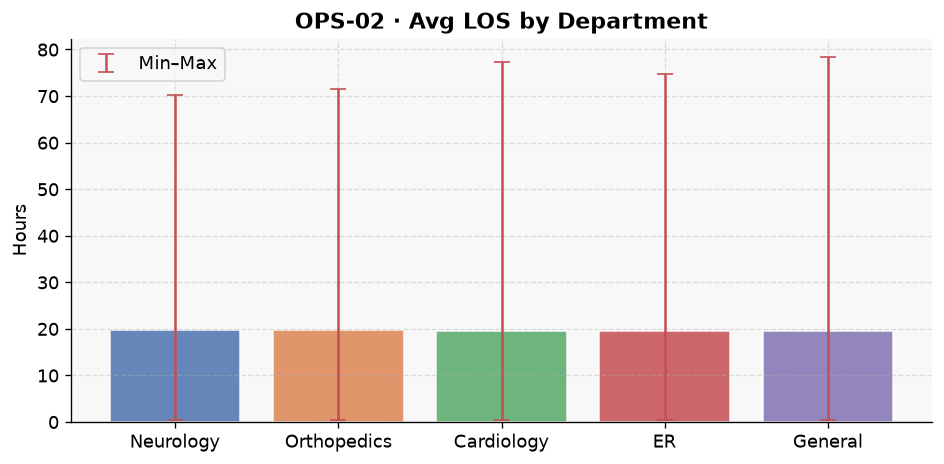

In [6]:
ops02 = run_query(con,
    "OPS-02 · Top 5 departments by average LOS (hours)",
    """
    SELECT department,
           COUNT(visit_id) AS total_visits,
           ROUND(AVG(length_of_stay_hours),2) AS avg_los_hours,
           ROUND(MIN(length_of_stay_hours),2) AS min_los_hours,
           ROUND(MAX(length_of_stay_hours),2) AS max_los_hours
    FROM visits WHERE length_of_stay_hours IS NOT NULL
    GROUP BY department ORDER BY avg_los_hours DESC LIMIT 5
    """,
    "Neurology (19.72 hrs) leads. All departments within 19.4–19.7 hr band.")

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(ops02['department'], ops02['avg_los_hours'], color=DEPT_COLORS[:5], edgecolor='white', alpha=0.85)
ax.errorbar(range(len(ops02)), ops02['avg_los_hours'],
            yerr=[ops02['avg_los_hours']-ops02['min_los_hours'],
                  ops02['max_los_hours']-ops02['avg_los_hours']],
            fmt='none', color='#C44E52', capsize=5, linewidth=1.5, label='Min–Max')
ax.set_ylabel('Hours'); ax.set_title('OPS-02 · Avg LOS by Department'); ax.legend()
plt.tight_layout(); plt.show()


### OPS-03 — High Risk % per Department


────────────────────────────────────────────────────────────
  OPS-03 · High Risk % per department
────────────────────────────────────────────────────────────


,department,total_visits,high_risk,medium_risk,low_risk,high_risk_pct
0,ICU,4064,845,1182,2037,20.79
1,ER,4220,872,1256,2092,20.66
2,Neurology,4165,846,1261,2058,20.31
3,Orthopedics,4164,842,1244,2078,20.22
4,General,4228,839,1266,2123,19.84
5,Cardiology,4159,790,1287,2082,18.99



💡 ICU (20.79%) leads High Risk %. All departments within a 2% band.


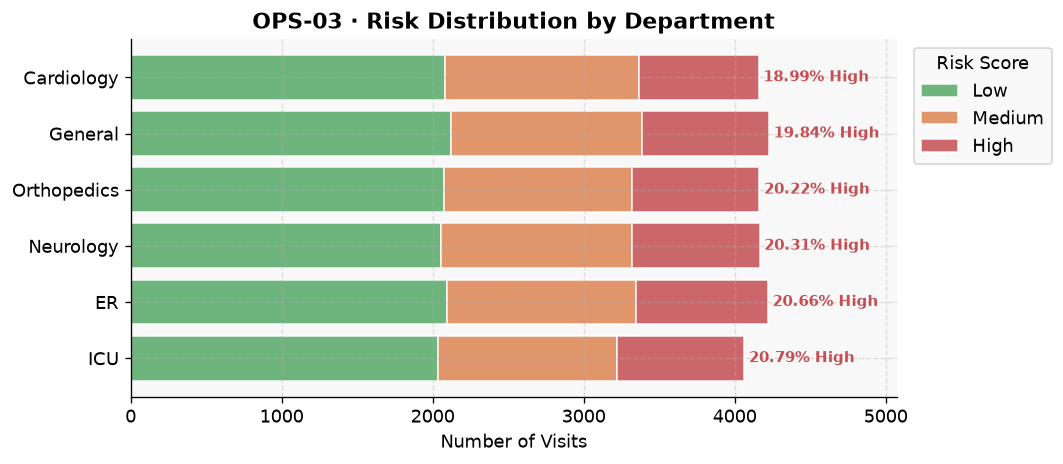

In [7]:
ops03 = run_query(con,
    "OPS-03 · High Risk % per department",
    """
    SELECT department, COUNT(visit_id) AS total_visits,
           SUM(CASE WHEN risk_score='High'   THEN 1 ELSE 0 END) AS high_risk,
           SUM(CASE WHEN risk_score='Medium' THEN 1 ELSE 0 END) AS medium_risk,
           SUM(CASE WHEN risk_score='Low'    THEN 1 ELSE 0 END) AS low_risk,
           ROUND(SUM(CASE WHEN risk_score='High' THEN 1 ELSE 0 END)*100.0/COUNT(visit_id),2) AS high_risk_pct
    FROM visits GROUP BY department ORDER BY high_risk_pct DESC
    """,
    "ICU (20.79%) leads High Risk %. All departments within a 2% band.")

fig, ax = plt.subplots(figsize=(9,4))
ax.barh(ops03['department'], ops03['low_risk'],    color=RISK_COLORS['Low'],    edgecolor='white', alpha=0.85, label='Low')
ax.barh(ops03['department'], ops03['medium_risk'], color=RISK_COLORS['Medium'], edgecolor='white', alpha=0.85, label='Medium', left=ops03['low_risk'])
ax.barh(ops03['department'], ops03['high_risk'],   color=RISK_COLORS['High'],   edgecolor='white', alpha=0.85, label='High',   left=ops03['low_risk']+ops03['medium_risk'])
ax.set_xlabel('Number of Visits'); ax.set_title('OPS-03 · Risk Distribution by Department')
ax.legend(title='Risk Score', bbox_to_anchor=(1.01,1))
for i,(_,row) in enumerate(ops03.iterrows()):
    ax.text(row['total_visits']+30,i,f"{row['high_risk_pct']}% High",va='center',fontsize=9,color='#C44E52',fontweight='bold')
ax.set_xlim(0,ops03['total_visits'].max()*1.2)
plt.tight_layout(); plt.show()


### OPS-04 — Average Visits per Patient by City


────────────────────────────────────────────────────────────
  OPS-04 · Average visits per patient by city
────────────────────────────────────────────────────────────


,city,total_patients,total_visits,avg_visits_per_patient,max_visits_single_patient
0,Pune,831,4221,5.08,15
1,Hyderabad,869,4370,5.03,14
2,Mumbai,822,4122,5.01,13
3,Bangalore,840,4205,5.01,14
4,Chennai,801,3975,4.96,12
5,Delhi,837,4107,4.91,12



💡 Pune leads at 5.08 avg visits/patient. Narrow range across all cities.


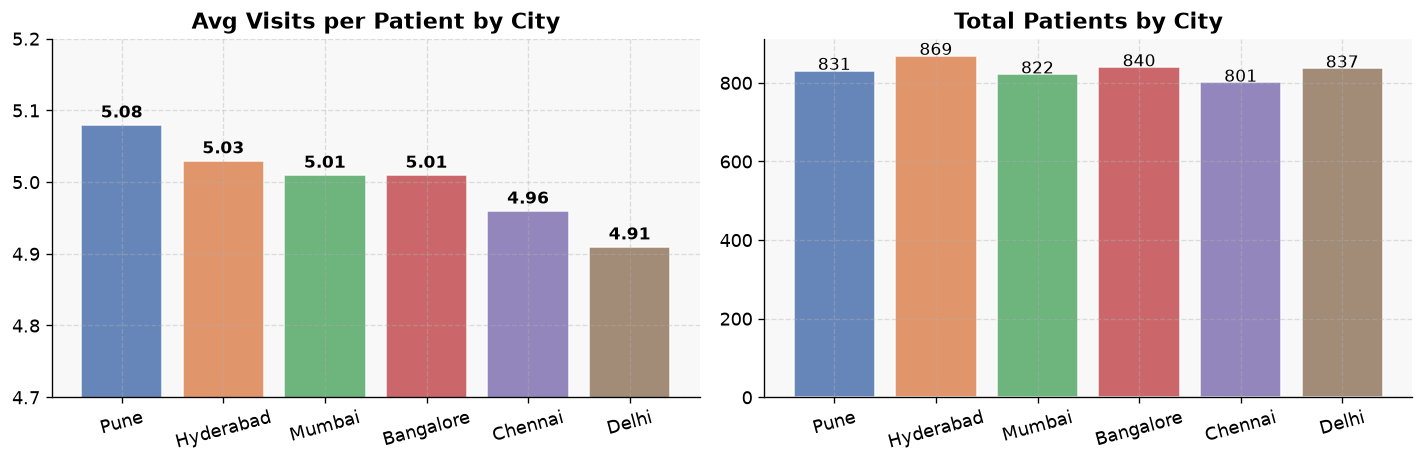

In [8]:
ops04 = run_query(con,
    "OPS-04 · Average visits per patient by city",
    """
    WITH pvc AS (
        SELECT p.city, p.patient_id, COUNT(v.visit_id) AS visit_count
        FROM patients p LEFT JOIN visits v ON p.patient_id=v.patient_id
        GROUP BY p.city, p.patient_id
    )
    SELECT city, COUNT(DISTINCT patient_id) AS total_patients,
           SUM(visit_count) AS total_visits,
           ROUND(AVG(visit_count),2) AS avg_visits_per_patient,
           MAX(visit_count) AS max_visits_single_patient
    FROM pvc GROUP BY city ORDER BY avg_visits_per_patient DESC
    """,
    "Pune leads at 5.08 avg visits/patient. Narrow range across all cities.")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(ops04['city'], ops04['avg_visits_per_patient'], color=DEPT_COLORS, edgecolor='white', alpha=0.85)
axes[0].set_title('Avg Visits per Patient by City'); axes[0].set_ylim(4.7,5.2); axes[0].tick_params(axis='x',rotation=15)
for i,v in enumerate(ops04['avg_visits_per_patient']): axes[0].text(i,v+0.01,f'{v}',ha='center',fontsize=10,fontweight='bold')
axes[1].bar(ops04['city'], ops04['total_patients'], color=DEPT_COLORS, edgecolor='white', alpha=0.85)
axes[1].set_title('Total Patients by City'); axes[1].tick_params(axis='x',rotation=15)
for i,v in enumerate(ops04['total_patients']): axes[1].text(i,v+2,f'{v:,}',ha='center',fontsize=10)
plt.tight_layout(); plt.show()


### OPS-05 — Doctors Handling Most High Risk Visits

In [9]:
ops05 = run_query(con,
    "OPS-05 · Top 10 doctors by High Risk visit count",
    """
    SELECT doctor_id, COUNT(visit_id) AS total_visits,
           SUM(CASE WHEN risk_score='High' THEN 1 ELSE 0 END) AS high_risk_visits,
           ROUND(SUM(CASE WHEN risk_score='High' THEN 1 ELSE 0 END)*100.0/COUNT(visit_id),2) AS high_risk_pct,
           COUNT(DISTINCT department) AS depts_covered
    FROM visits GROUP BY doctor_id ORDER BY high_risk_visits DESC LIMIT 10
    """,
    "Doctor 174 handles the most High Risk visits (71). All top 10 are generalists.")



────────────────────────────────────────────────────────────
  OPS-05 · Top 10 doctors by High Risk visit count
────────────────────────────────────────────────────────────


,doctor_id,total_visits,high_risk_visits,high_risk_pct,depts_covered
0,174,264,71,26.89,6
1,198,252,69,27.38,6
2,169,279,68,24.37,6
3,177,266,67,25.19,6
4,135,261,65,24.90,6
5,105,250,65,26.00,6
6,188,285,64,22.46,6
7,180,290,64,22.07,6
8,131,266,62,23.31,6
9,178,245,61,24.90,6



💡 Doctor 174 handles the most High Risk visits (71). All top 10 are generalists.


## 5. Financial Analysis Queries

### FIN-01 — Top Insurers by Total Billed Amount


────────────────────────────────────────────────────────────
  FIN-01 · Top insurers by total billed amount
────────────────────────────────────────────────────────────


,insurance_provider,total_patients,total_claims,total_billed,avg_billed_per_claim
0,MediCareX,1281,6532,"134,591,163.08","20,604.89"
1,CareOne,1255,6283,"130,707,992.64","20,803.44"
2,HealthPlus,1241,6220,"130,180,740.75","20,929.38"
3,SecureLife,1190,5965,"126,289,039.58","21,171.67"



💡 MediCareX bills most (₹13.46 Cr). SecureLife has highest avg bill per claim.


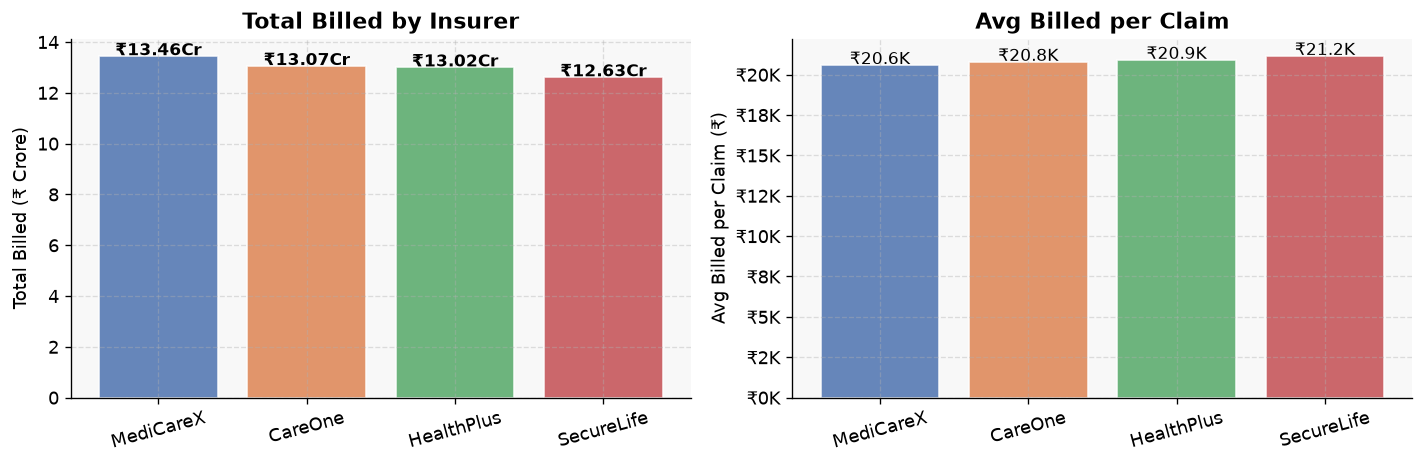

In [10]:
fin01 = run_query(con,
    "FIN-01 · Top insurers by total billed amount",
    """
    SELECT p.insurance_provider,
           COUNT(DISTINCT p.patient_id) AS total_patients,
           COUNT(b.bill_id) AS total_claims,
           ROUND(SUM(b.billed_amount),2) AS total_billed,
           ROUND(AVG(b.billed_amount),2) AS avg_billed_per_claim
    FROM patients p JOIN visits v ON p.patient_id=v.patient_id
    JOIN billing b ON v.visit_id=b.visit_id
    GROUP BY p.insurance_provider ORDER BY total_billed DESC
    """,
    "MediCareX bills most (₹13.46 Cr). SecureLife has highest avg bill per claim.")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(fin01['insurance_provider'], fin01['total_billed']/1e7, color=INS_COLORS, edgecolor='white', alpha=0.85)
axes[0].set_ylabel('Total Billed (₹ Crore)'); axes[0].set_title('Total Billed by Insurer'); axes[0].tick_params(axis='x',rotation=15)
for i,v in enumerate(fin01['total_billed']/1e7): axes[0].text(i,v+0.02,f'₹{v:.2f}Cr',ha='center',fontsize=10,fontweight='bold')
axes[1].bar(fin01['insurance_provider'], fin01['avg_billed_per_claim'], color=INS_COLORS, edgecolor='white', alpha=0.85)
axes[1].set_ylabel('Avg Billed per Claim (₹)'); axes[1].set_title('Avg Billed per Claim'); axes[1].tick_params(axis='x',rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
for i,v in enumerate(fin01['avg_billed_per_claim']): axes[1].text(i,v+50,f'₹{v/1000:.1f}K',ha='center',fontsize=10)
plt.tight_layout(); plt.show()


### FIN-02 — Top Insurers by Claim Rejection Rate

In [11]:
fin02 = run_query(con,
    "FIN-02 · Top insurers by rejection rate",
    """
    SELECT p.insurance_provider, COUNT(b.bill_id) AS total_claims,
           SUM(CASE WHEN b.claim_status='Rejected' THEN 1 ELSE 0 END) AS rejected,
           SUM(CASE WHEN b.claim_status='Paid'     THEN 1 ELSE 0 END) AS paid,
           SUM(CASE WHEN b.claim_status='Pending'  THEN 1 ELSE 0 END) AS pending,
           ROUND(SUM(CASE WHEN b.claim_status='Rejected' THEN 1 ELSE 0 END)*100.0/COUNT(b.bill_id),2) AS rejection_rate_pct
    FROM patients p JOIN visits v ON p.patient_id=v.patient_id
    JOIN billing b ON v.visit_id=b.visit_id
    GROUP BY p.insurance_provider ORDER BY rejection_rate_pct DESC
    """,
    "SecureLife 15.69% vs CareOne 14.87% — narrow band = systemic hospital issue.")



────────────────────────────────────────────────────────────
  FIN-02 · Top insurers by rejection rate
────────────────────────────────────────────────────────────


,insurance_provider,total_claims,rejected,paid,pending,rejection_rate_pct
0,SecureLife,5965,936,3598,1431,15.69
1,MediCareX,6532,996,3875,1661,15.25
2,HealthPlus,6220,931,3680,1609,14.97
3,CareOne,6283,934,3787,1562,14.87



💡 SecureLife 15.69% vs CareOne 14.87% — narrow band = systemic hospital issue.


### FIN-03 — Average Payment Delay by Insurer

In [12]:
fin03 = run_query(con,
    "FIN-03 · Avg payment delay by insurer",
    """
    SELECT p.insurance_provider, COUNT(b.bill_id) AS total_claims,
           SUM(CASE WHEN b.payment_days IS NULL THEN 1 ELSE 0 END) AS claims_unpaid,
           ROUND(AVG(b.payment_days),2) AS avg_payment_days,
           ROUND(MIN(b.payment_days),2) AS min_payment_days,
           ROUND(MAX(b.payment_days),2) AS max_payment_days
    FROM patients p JOIN visits v ON p.patient_id=v.patient_id
    JOIN billing b ON v.visit_id=b.visit_id
    GROUP BY p.insurance_provider ORDER BY avg_payment_days DESC
    """,
    "All insurers ~13 days avg. Max delays 49–55 days are outliers.")



────────────────────────────────────────────────────────────
  FIN-03 · Avg payment delay by insurer
────────────────────────────────────────────────────────────


,insurance_provider,total_claims,claims_unpaid,avg_payment_days,min_payment_days,max_payment_days
0,SecureLife,5965,180,13.08,1.00,53.00
1,HealthPlus,6220,220,13.08,1.00,51.00
2,CareOne,6283,184,13.03,1.00,49.00
3,MediCareX,6532,206,13.01,1.00,55.00



💡 All insurers ~13 days avg. Max delays 49–55 days are outliers.


### FIN-04 — Revenue Realization Ratio by Department

In [13]:
fin04 = run_query(con,
    "FIN-04 · Revenue realization ratio by department",
    """
    SELECT v.department, COUNT(b.bill_id) AS total_claims,
           ROUND(SUM(b.billed_amount),2)   AS total_billed,
           ROUND(SUM(b.approved_amount),2) AS total_approved,
           ROUND(SUM(b.approved_amount)*1.0/NULLIF(SUM(b.billed_amount),0),4) AS realization_ratio,
           ROUND((1-SUM(b.approved_amount)*1.0/NULLIF(SUM(b.billed_amount),0))*100,2) AS leakage_pct
    FROM visits v JOIN billing b ON v.visit_id=b.visit_id
    WHERE b.approved_amount IS NOT NULL
    GROUP BY v.department ORDER BY realization_ratio ASC
    """,
    "Cardiology worst at 78.04%. All depts between 78.0–78.5% — systemic 22% leakage.")



────────────────────────────────────────────────────────────
  FIN-04 · Revenue realization ratio by department
────────────────────────────────────────────────────────────


,department,total_claims,total_billed,total_approved,realization_ratio,leakage_pct
0,Cardiology,3935,"81,632,263.84","63,705,806.68",0.78,21.96
1,Neurology,3950,"82,821,225.52","64,708,778.69",0.78,21.87
2,Orthopedics,3949,"83,392,410.45","65,211,585.83",0.78,21.80
3,General,4004,"82,669,228.09","64,690,870.95",0.78,21.75
4,ER,3990,"83,745,346.56","65,672,329.38",0.78,21.58
5,ICU,3854,"80,508,666.87","63,166,516.84",0.78,21.54



💡 Cardiology worst at 78.04%. All depts between 78.0–78.5% — systemic 22% leakage.


### FIN-05 — High-Billed Visits with Zero or Null Approval

In [14]:
fin05 = run_query(con,
    "FIN-05 · High-billed visits with zero/null approved amount (top 15)",
    """
    SELECT v.visit_id, v.department, v.visit_type, v.risk_score,
           p.insurance_provider,
           ROUND(b.billed_amount,2) AS billed_amount,
           b.approved_amount, b.claim_status, b.billing_date
    FROM visits v JOIN patients p ON v.patient_id=p.patient_id
    JOIN billing b ON v.visit_id=b.visit_id
    WHERE b.billed_amount > (SELECT AVG(billed_amount) FROM billing)
      AND (b.approved_amount IS NULL OR b.approved_amount=0)
    ORDER BY b.billed_amount DESC LIMIT 15
    """,
    "These are the highest-priority revenue leakage cases for the finance team.")



────────────────────────────────────────────────────────────
  FIN-05 · High-billed visits with zero/null approved amount (top 15)
────────────────────────────────────────────────────────────


,visit_id,department,visit_type,risk_score,insurance_provider,billed_amount,approved_amount,claim_status,billing_date
0,1570,General,OPD,Medium,HealthPlus,"78,054.79",NaN,Paid,2025-05-19
1,18381,General,ER,Low,HealthPlus,"68,213.53",0.00,Rejected,2025-02-06
2,15092,Neurology,ICU,High,CareOne,"66,410.33",NaN,Paid,2025-06-05
3,2638,Neurology,OPD,Low,CareOne,"65,167.44",NaN,Paid,2025-06-03
4,8089,ER,ER,Low,HealthPlus,"62,661.81",NaN,Paid,2025-05-10
5,19310,ICU,OPD,Medium,MediCareX,"60,510.22",NaN,Paid,2025-01-29
6,24623,Neurology,ICU,Low,SecureLife,"58,275.40",NaN,Paid,2025-09-24
7,18189,Neurology,ICU,Medium,HealthPlus,"57,521.12",NaN,Paid,2025-10-13
8,14702,Orthopedics,OPD,Medium,HealthPlus,"56,848.91",NaN,Paid,2026-01-19
9,5131,Orthopedics,ER,High,MediCareX,"56,736.52",NaN,Paid,2025-12-17



💡 These are the highest-priority revenue leakage cases for the finance team.


## 6. Data Quality & Integrity Checks

In [15]:
dq01 = run_query(con, "DQ-01 · Visits without billing records",
    "SELECT COUNT(*) AS visits_without_billing FROM visits v LEFT JOIN billing b ON v.visit_id=b.visit_id WHERE b.bill_id IS NULL",
    "✅ Expected 0. Every visit must have a billing record.")

dq02 = run_query(con, "DQ-02 · Orphan billing records (no matching visit)",
    "SELECT COUNT(*) AS orphan_billing_records FROM billing b LEFT JOIN visits v ON b.visit_id=v.visit_id WHERE v.visit_id IS NULL",
    "✅ Expected 0. No bill should exist without a visit.")

dq03 = run_query(con, "DQ-03 · Duplicate patient_ids",
    "SELECT patient_id, COUNT(*) AS count FROM patients GROUP BY patient_id HAVING COUNT(*) > 1",
    "✅ Expected 0 rows. patient_id is the primary key and must be unique.")
if dq03.empty: print("✅ No duplicate patient_ids found.")

dq04 = run_query(con, "DQ-04 · Missing / invalid field summary",
    """
    SELECT 'visits'  AS source_table, 'length_of_stay_hours' AS field_name,
           COUNT(*)  AS total_records,
           SUM(CASE WHEN length_of_stay_hours IS NULL OR length_of_stay_hours<=0 THEN 1 ELSE 0 END) AS invalid_count,
           ROUND(SUM(CASE WHEN length_of_stay_hours IS NULL OR length_of_stay_hours<=0 THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS invalid_pct
    FROM visits
    UNION ALL
    SELECT 'billing','payment_days',COUNT(*),
           SUM(CASE WHEN payment_days IS NULL OR payment_days<0 THEN 1 ELSE 0 END),
           ROUND(SUM(CASE WHEN payment_days IS NULL OR payment_days<0 THEN 1 ELSE 0 END)*100.0/COUNT(*),2)
    FROM billing
    UNION ALL
    SELECT 'billing','approved_amount',COUNT(*),
           SUM(CASE WHEN approved_amount IS NULL THEN 1 ELSE 0 END),
           ROUND(SUM(CASE WHEN approved_amount IS NULL THEN 1 ELSE 0 END)*100.0/COUNT(*),2)
    FROM billing
    """,
    "payment_days 3.16% and approved_amount 5.27% are INFORMATIVE nulls — handle in Phase 2.")

dq05 = run_query(con, "DQ-05 · Visits with missing insurance provider",
    """SELECT COUNT(*) AS visits_missing_insurance FROM visits v JOIN patients p ON v.patient_id=p.patient_id
    WHERE p.insurance_provider IS NULL OR TRIM(p.insurance_provider)='' """,
    "✅ Expected 0. All patients must have an insurance provider.")



────────────────────────────────────────────────────────────
  DQ-01 · Visits without billing records
────────────────────────────────────────────────────────────


,visits_without_billing
0,0



💡 ✅ Expected 0. Every visit must have a billing record.

────────────────────────────────────────────────────────────
  DQ-02 · Orphan billing records (no matching visit)
────────────────────────────────────────────────────────────


,orphan_billing_records
0,0



💡 ✅ Expected 0. No bill should exist without a visit.

────────────────────────────────────────────────────────────
  DQ-03 · Duplicate patient_ids
────────────────────────────────────────────────────────────


...


💡 ✅ Expected 0 rows. patient_id is the primary key and must be unique.
✅ No duplicate patient_ids found.

────────────────────────────────────────────────────────────
  DQ-04 · Missing / invalid field summary
────────────────────────────────────────────────────────────


,source_table,field_name,total_records,invalid_count,invalid_pct
0,visits,length_of_stay_hours,25000,0,0.00
1,billing,payment_days,25000,790,3.16
2,billing,approved_amount,25000,1318,5.27



💡 payment_days 3.16% and approved_amount 5.27% are INFORMATIVE nulls — handle in Phase 2.

────────────────────────────────────────────────────────────
  DQ-05 · Visits with missing insurance provider
────────────────────────────────────────────────────────────


,visits_missing_insurance
0,0



💡 ✅ Expected 0. All patients must have an insurance provider.


## 7. Executive KPI Dashboard


────────────────────────────────────────────────────────────
  DASHBOARD · Overall Hospital KPI Snapshot
────────────────────────────────────────────────────────────


,total_patients,total_visits,total_bills,total_billed,total_approved,realization_ratio,rejection_rate_pct,avg_los_hours,high_risk_visit_pct
0,5000,25000,25000,"521,768,936.05","387,155,888.37",0.78,15.19,19.55,20.14


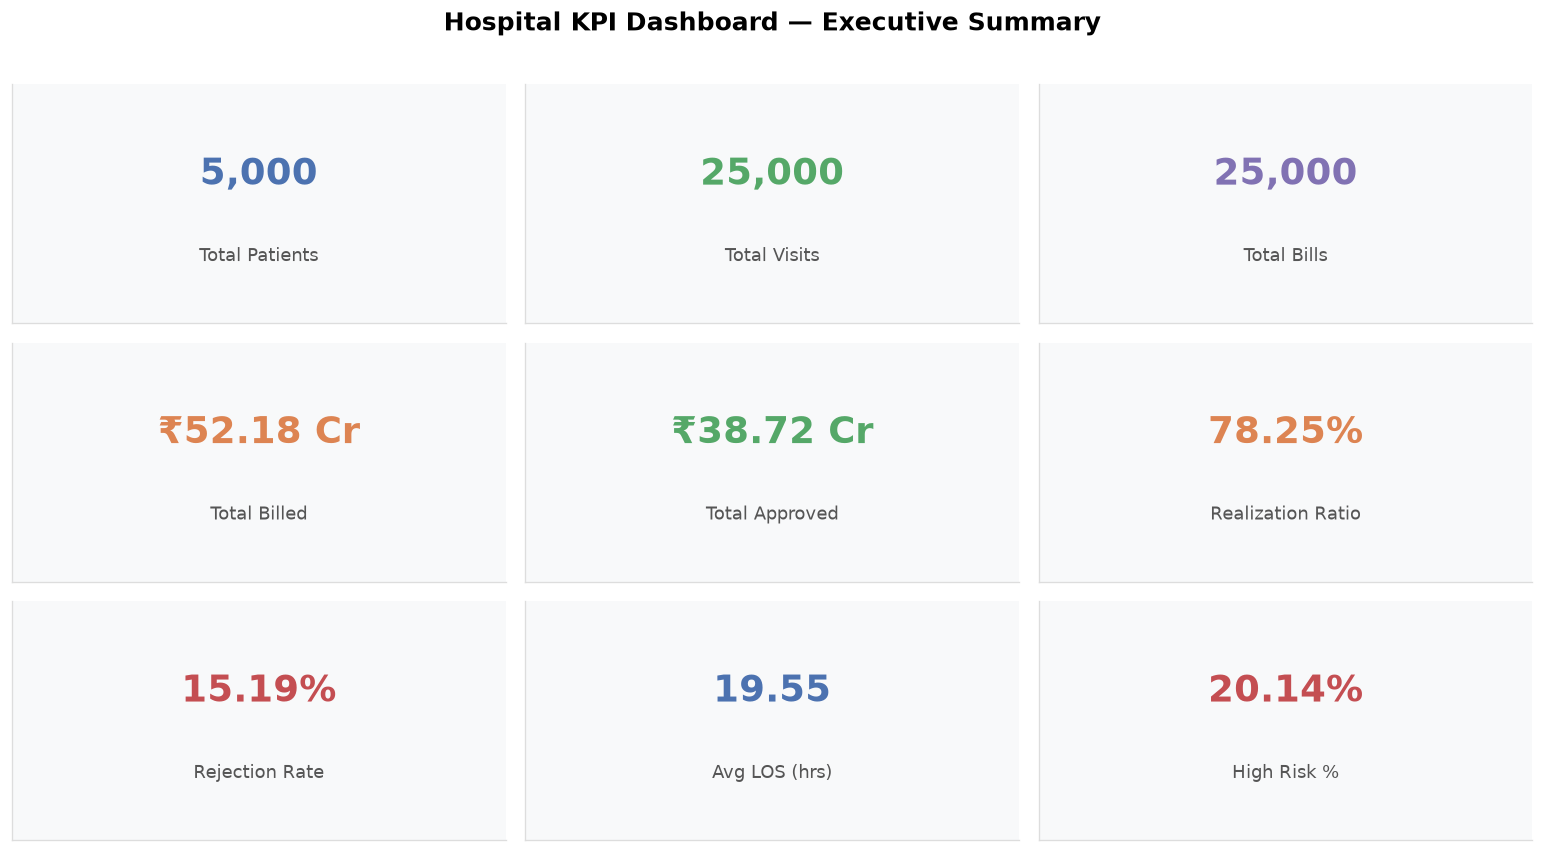

In [16]:
kpi = run_query(con, "DASHBOARD · Overall Hospital KPI Snapshot",
    """
    SELECT
        (SELECT COUNT(*) FROM patients)  AS total_patients,
        (SELECT COUNT(*) FROM visits)    AS total_visits,
        (SELECT COUNT(*) FROM billing)   AS total_bills,
        (SELECT ROUND(SUM(billed_amount),2)   FROM billing)  AS total_billed,
        (SELECT ROUND(SUM(approved_amount),2) FROM billing WHERE approved_amount IS NOT NULL) AS total_approved,
        (SELECT ROUND(SUM(approved_amount)*1.0/NULLIF(SUM(billed_amount),0),4) FROM billing WHERE approved_amount IS NOT NULL) AS realization_ratio,
        (SELECT ROUND(SUM(CASE WHEN claim_status='Rejected' THEN 1.0 ELSE 0 END)/COUNT(*)*100,2) FROM billing) AS rejection_rate_pct,
        (SELECT ROUND(AVG(length_of_stay_hours),2) FROM visits WHERE length_of_stay_hours IS NOT NULL) AS avg_los_hours,
        (SELECT ROUND(SUM(CASE WHEN risk_score='High' THEN 1.0 ELSE 0 END)/COUNT(*)*100,2) FROM visits) AS high_risk_visit_pct
    """)

row = kpi.iloc[0]
kpis = [
    ("Total Patients",    f"{int(row['total_patients']):,}",       '#4C72B0'),
    ("Total Visits",      f"{int(row['total_visits']):,}",         '#55A868'),
    ("Total Bills",       f"{int(row['total_bills']):,}",          '#8172B3'),
    ("Total Billed",      f"₹{row['total_billed']/1e7:.2f} Cr",   '#DD8452'),
    ("Total Approved",    f"₹{row['total_approved']/1e7:.2f} Cr", '#55A868'),
    ("Realization Ratio", f"{row['realization_ratio']*100:.2f}%",  '#DD8452'),
    ("Rejection Rate",    f"{row['rejection_rate_pct']}%",         '#C44E52'),
    ("Avg LOS (hrs)",     f"{row['avg_los_hours']}",               '#4C72B0'),
    ("High Risk %",       f"{row['high_risk_visit_pct']}%",        '#C44E52'),
]
fig, axes = plt.subplots(3,3,figsize=(13,7))
fig.suptitle('Hospital KPI Dashboard — Executive Summary', fontsize=15, fontweight='bold', y=1.01)
for ax,(label,value,color) in zip(axes.flat, kpis):
    ax.set_facecolor('#f8f9fa')
    ax.text(0.5,0.62,value,ha='center',va='center',fontsize=22,fontweight='bold',color=color,transform=ax.transAxes)
    ax.text(0.5,0.28,label,ha='center',va='center',fontsize=11,color='#555555',transform=ax.transAxes)
    for spine in ax.spines.values(): spine.set_edgecolor('#dddddd')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 8. Phase 1 Summary

| Component | Details |
|---|---|
| Source | `phase1_utils.py` — all setup, one import line |
| Database | SQLite in-memory, 3 tables, 7 indexes, 2 views |
| Queries | 15 total — 5 operational, 5 financial, 5 data quality |
| Key finding | ₹52.2 Cr billed → only 78.3% realized = **~₹11.4 Cr leakage** |
| Rejection rate | 15.2% consistent across all insurers = systemic billing issue |
| Data quality | Zero orphans, zero duplicates. Two null fields (handled in Phase 2) |
| Next | Phase 2 — `01_eda.ipynb` — imports same `phase1_utils.py` |
